In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind
from statsmodels.stats.power import TTestIndPower
from statsmodels.stats.multitest import multipletests


df = pd.read_csv('/content/marketpele_ab.csv')
df.head(3)

,date,publisher_id,platform,group_name,pageviews,visible_pageviews,sessions,revenue,sponsord_clicks,organic_clicks,RPM
0,2019-03-01,101,Desktop,A,16580.0,5418.0,12684.0,3452.0,300,849,637.135474
1,2019-03-01,101,Desktop,B,16191.0,4906.0,12717.0,3292.0,268,555,671.015084
2,2019-03-01,106,Desktop,A,16227.0,11395.0,11750.0,2016.0,601,2425,176.919702


In [4]:
# Метрики на уровне каждой строки-агрегата
# df['RPM'] = df['revenue'] / df['visible_pageviews'] * 1000 метрика рассчитана в файле 02_sanity_check.ipynb
df['RPS'] = (df['revenue'] / df['sessions']) * 1000
df['Paid_CTR'] = df['sponsord_clicks'] / df['visible_pageviews']
df['Organic_CTR'] = df['organic_clicks'] / df['visible_pageviews']
df['Views_per_Session'] = df['visible_pageviews'] / df['sessions']
df['Visibility_rate'] = df['visible_pageviews'] / df['pageviews']

# Сводка по группам A/B
metrics = ['RPM', 'RPS', 'Paid_CTR', 'Organic_CTR', 'Views_per_Session', 'Visibility_rate']
summary = df.groupby('group_name')[metrics].agg(['mean', 'std', 'count'])
print(summary.round(2))

               RPM                   RPS               Paid_CTR              \
              mean     std count    mean     std count     mean   std count   
group_name                                                                    
A           666.89  548.76    63  490.26  465.80    63     0.06  0.03    63   
B           813.03  709.86    63  550.16  569.66    63     0.07  0.03    63   

           Organic_CTR             Views_per_Session              \
                  mean   std count              mean   std count   
group_name                                                         
A                  0.2  0.04    63              1.04  1.50    63   
B                  0.1  0.03    63              0.85  1.08    63   

           Visibility_rate              
                      mean   std count  
group_name                              
A                     0.34  0.16    63  
B                     0.33  0.17    63  


Visibility Rate почти одинаковый – можно сравнивать RPM напрямую

**Графики** **распределений**

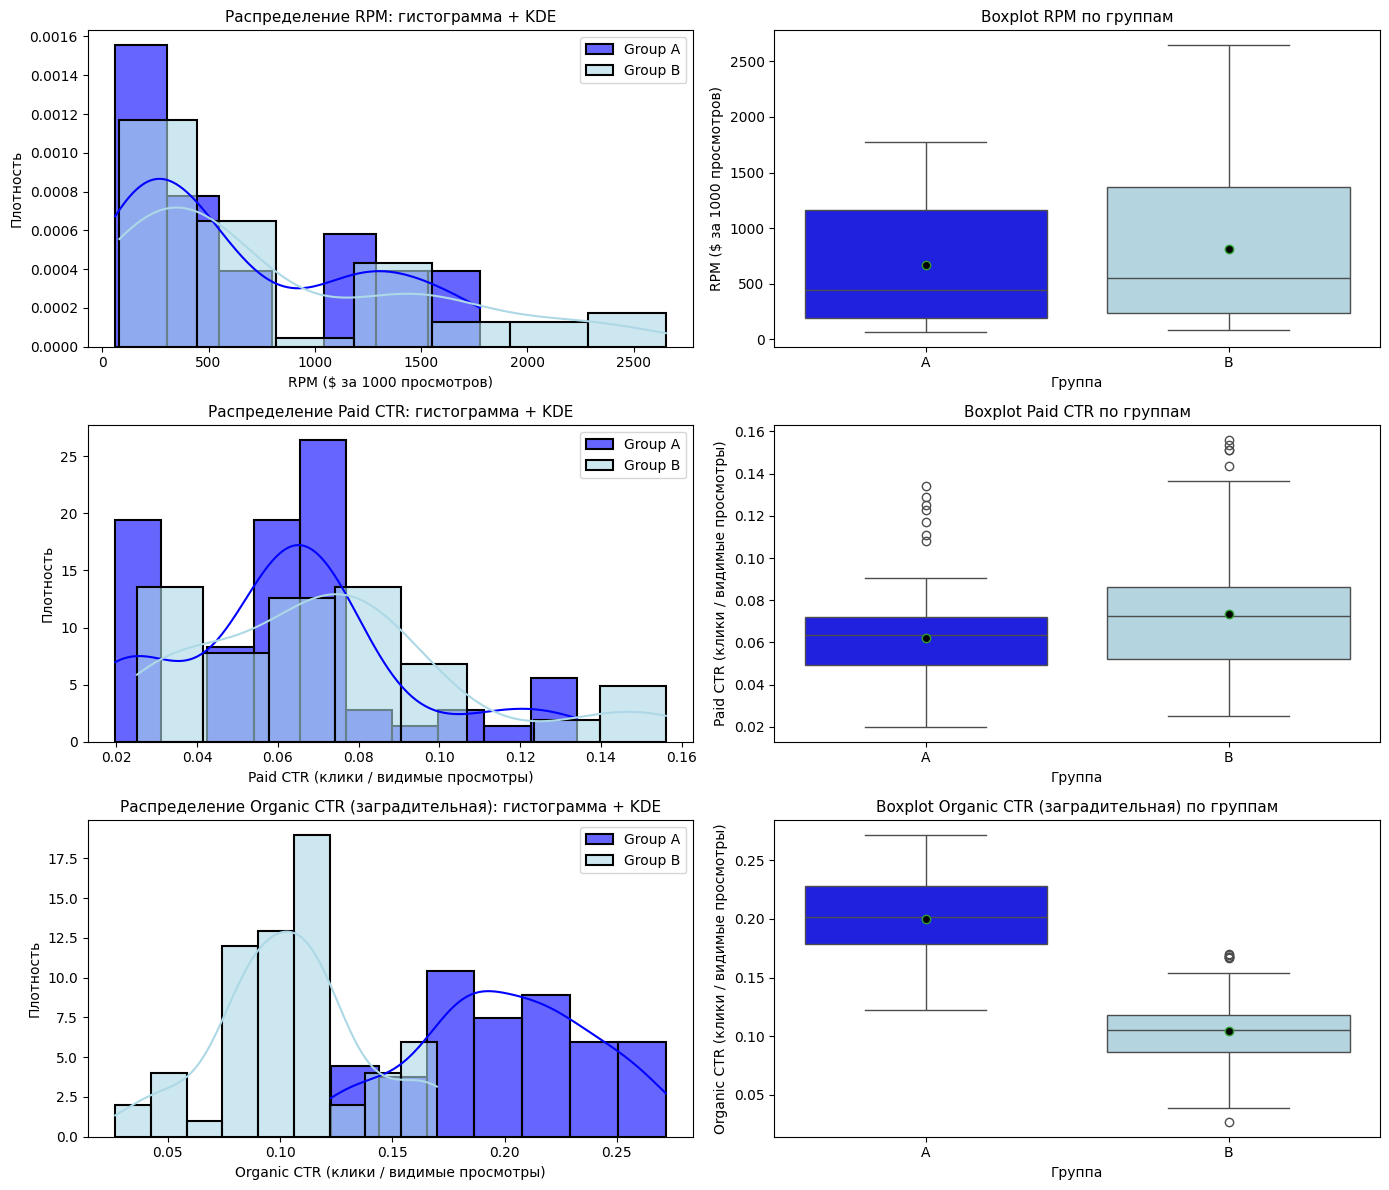

In [12]:
metrics = {
    'RPM': {'ylabel': 'RPM ($ за 1000 просмотров)', 'title': 'RPM'},
    'Paid_CTR': {'ylabel': 'Paid CTR (клики / видимые просмотры)', 'title': 'Paid CTR'},
    'Organic_CTR': {'ylabel': 'Organic CTR (клики / видимые просмотры)', 'title': 'Organic CTR (заградительная)'}
}

colors = {'A': 'blue', 'B': 'lightblue'}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for idx, (metric, props) in enumerate(metrics.items()):
    # Гистограмма + KDE
    for group in ['A', 'B']:
        data = df[df['group_name'] == group][metric]
        sns.histplot(data=data, kde=True, label=f'Group {group}',
                     ax=axes[idx, 0], alpha=0.6, color=colors[group],
                     stat='density', linewidth=1.5)
    axes[idx, 0].set_title(f'Распределение {props["title"]}: гистограмма + KDE', fontsize=11)
    axes[idx, 0].set_xlabel(props['ylabel'])
    axes[idx, 0].set_ylabel('Плотность')
    axes[idx, 0].legend()

    # Boxplot
    sns.boxplot(x='group_name', y=metric, data=df, ax=axes[idx, 1],
                hue='group_name', palette=colors, legend=False,
                showmeans=True, meanprops={'marker':'o', 'markerfacecolor':'black', 'markersize':6})
    axes[idx, 1].set_title(f'Boxplot {props["title"]} по группам', fontsize=11)
    axes[idx, 1].set_ylabel(props['ylabel'])
    axes[idx, 1].set_xlabel('Группа')

plt.tight_layout()
plt.show()

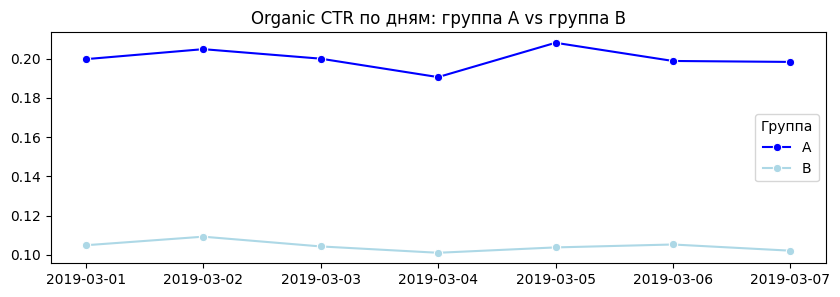

In [ ]:
organic_daily = df.groupby(['date', 'group_name'])['Organic_CTR'].mean().reset_index()

plt.figure(figsize=(10, 3))

sns.lineplot(data=organic_daily, x='date', y='Organic_CTR', hue='group_name', marker='o', palette=colors)

plt.title('Organic CTR по дням: группа A vs группа B')
plt.xlabel('')
plt.ylabel('')
plt.legend(title='Группа')
plt.show()

In [32]:
# Опираясь на ЦПТ используем t-test Уэлча +  бутстрап ДИ + пермутационный тест для валидации + FDR поправка
np.random.seed(42)

def bootstrap_ci(group1, group2, n_boot=5000, alpha=0.05):
    diff_obs = group2.mean() - group1.mean()
    diffs = [
        np.random.choice(group2, len(group2), replace=True).mean() -
        np.random.choice(group1, len(group1), replace=True).mean()
        for _ in range(n_boot)
    ]
    return diff_obs, *np.percentile(diffs, [100 * alpha / 2, 100 * (1 - alpha / 2)])

def permutation_test(group1, group2, n_perm=2000):
    obs_diff = abs(group2.mean() - group1.mean())
    combined = np.concatenate([group1, group2])
    count = 0
    for _ in range(n_perm):
        np.random.shuffle(combined)
        perm_diff = abs(combined[:len(group1)].mean() - combined[len(group1):].mean())
        if perm_diff >= obs_diff:
            count += 1
    return count / n_perm

metrics = {
    'RPM': ('revenue', 'visible_pageviews', 1000, 'absolute'),
    'Paid_CTR': ('sponsord_clicks', 'visible_pageviews', 1, 'percent'),
    'Organic_CTR': ('organic_clicks', 'visible_pageviews', 1, 'percent')
}

results, p_vals, perm_p_vals = [], [], []

for name, (num_col, den_col, mult, fmt) in metrics.items():
    df[f'{name}_val'] = df[num_col] / df[den_col] * mult
    a = df[df['group_name'] == 'A'][f'{name}_val']
    b = df[df['group_name'] == 'B'][f'{name}_val']

    _, p_welch = ttest_ind(a, b, equal_var=False) # t-test
    p_vals.append(p_welch)

    diff, ci_l, ci_h = bootstrap_ci(a, b)
    p_perm = permutation_test(a, b)
    perm_p_vals.append(p_perm)

    if fmt == 'percent':
        a_disp, b_disp = f"{a.mean() * 100:.2f}%", f"{b.mean() * 100:.2f}%"
        diff_disp, ci_disp = f"{diff * 100:+.2f} п.п.", f"[{ci_l * 100:.2f}%; {ci_h * 100:.2f}%]"
    else:
        a_disp, b_disp = f"${a.mean():.1f}", f"${b.mean():.1f}"
        diff_disp, ci_disp = f"${diff:+.1f}", f"[${ci_l:.1f}; ${ci_h:.1f}]"

    results.append({
        'Метрика': name, 'A': a_disp, 'B': b_disp, 'Δ (абс)': diff_disp,
        'Δ (%)': f"{diff / a.mean() * 100:+.1f}%", 'p (Welch)': p_welch,
        'p (perm)': p_perm, 'CI_95': ci_disp
    })

reject, p_adj, _, _ = multipletests(p_vals, method='fdr_bh')
for i, name in enumerate(metrics.keys()):
    results[i].update({'p-adj(FDR)': f"{p_adj[i]:.4f}", 'Значимо?': '✅' if reject[i] else '❌'})

res_df = pd.DataFrame(results)

print(res_df[['Метрика', 'A', 'B', 'Δ (абс)', 'Δ (%)', 'p (Welch)', 'p-adj(FDR)', 'p (perm)', 'CI_95', 'Значимо?']].to_markdown(index=False))

| Метрика     | A      | B      | Δ (абс)    | Δ (%)   |   p (Welch) |   p-adj(FDR) |   p (perm) | CI_95             | Значимо?   |
|:------------|:-------|:-------|:-----------|:--------|------------:|-------------:|-----------:|:------------------|:-----------|
| RPM         | $666.9 | $813.0 | $+146.1    | +21.9%  | 0.198625    |       0.1986 |     0.211  | [$-71.4; $360.9]  | ❌         |
| Paid_CTR    | 6.21%  | 7.34%  | +1.13 п.п. | +18.2%  | 0.0435566   |       0.0653 |     0.0415 | [0.05%; 2.24%]    | ❌         |
| Organic_CTR | 20.01% | 10.44% | -9.57 п.п. | -47.8%  | 2.44869e-29 |       0      |     0      | [-10.80%; -8.32%] | ✅         |


**RPM (25%)**: тест был «слаб» для детектирования эффекта +22% при высокой волатильности (CV=0.82). Не значимость ≠ отсутствие эффекта.
- **Paid CTR (53%)**: средняя чувствительность. Сигнал есть, но для надёжного подтверждения нужна большая выборка.
- **Organic CTR (~100%)**: эффект настолько сильный, что детектируется даже при малой выборке. Риск подтверждён.

In [72]:
# Проверяем, везде ли падает Organic CTR
seg_check = df.groupby(['group_name', 'platform'])['Organic_CTR'].mean().unstack()
print("Organic CTR по платформам:")
print(seg_check.round(3))

# Быстрый чек: в какой доле строк группа B хуже группы A?
# (сопоставляем по publisher+platform+date, если бы был парный дизайн)
# Но у нас независимые выборки, поэтому просто смотрим распределение:
print(f"\nДоля наблюдений с органическим кликом в группе А: {(df[df['group_name'] == 'A']['Organic_CTR'] > 0).mean()*100:.1f}%")
print(f"Доля наблюдений с органическим кликом в группе В: {(df[df['group_name'] == 'B']['Organic_CTR'] > 0).mean()*100:.1f}%")

Organic CTR по платформам:
platform    Desktop  Mobile
group_name                 
A             0.185   0.219
B             0.098   0.112

Доля наблюдений с органическим кликом в группе А: 100.0%
Доля наблюдений с органическим кликом в группе В: 100.0%


In [ ]:
# Сегментный анализ по издателям
seg_by_publisher = df.groupby(['group_name', 'publisher_id'])['Organic_CTR'].mean().unstack()
print(seg_by_publisher.T.sort_values('A', ascending=False).head(10))

group_name           A         B
publisher_id                    
574           0.258112  0.166042
373           0.234009  0.132561
259           0.213195  0.112831
106           0.205928  0.095414
700           0.203507  0.084678
123           0.179875  0.097608
101           0.167716  0.109356
111           0.132443  0.045737


Падение органического CTR — статистически значимый, устойчивый и системный эффект. Пользователи в группе B кликают по органическому контенту вдвое реже. Доля строк с хотя бы одним органическим кликом — 100% в обеих группах → реклама «перехватывает» внимание, а не блокирует контент технически.

Падение Organic CTR наблюдается у всех 8 издателей (0% позитивных случаев)

**Оценка потенциального влияния (в деньгах)**

In [47]:
# Данные из таблицы выше
total_views = df['visible_pageviews'].sum()
delta_rpm = 146.1
delta_ctr = 0.1044 - 0.2001  # -0.0957 (абсолютная разница)

# Потенциальный прирост дохода (если эффект реален)
weekly_gain = delta_rpm * (total_views / 1000)
monthly_gain = weekly_gain * 4.33  # ~4.33 недели в месяце

# Потеря органических кликов
lost_clicks = total_views * abs(delta_ctr)


# Диапазон ценности возврата (консервативный → оптимистичный)
value_range = [0.01, 0.04, 0.10]  # $ за возвратный клик
return_rate = 0.15

'''Расчёт: 92,000 кликов × 15% (доля возвратов) × $0.01–0.10 (оценочная ценность возврата).
Диапазон отражает неопределённость в оценке долгосрочного эффекта. Реальный ущерб может быть выше,
если учесть влияние на лояльность, LTV и SEO-ранжирование.'''

losses = [lost_clicks * return_rate * v for v in value_range]

# Вывод

print(f"Общий трафик в неделю: {total_views:,} просмотров")
print(f"Потенциальный прирост дохода: ${weekly_gain:,.0f}/неделю")
print(f"Потеря органических кликов/неделю: ~{lost_clicks:,.0f}")
print(f"Оценка ущерба от потери органики: ${losses[0]:,.0f} – ${losses[2]:,.0f}/неделю")
print(f"\n95% ДИ для прироста дохода: [${-71.4 * total_views/1000:,.0f}; ${360.9 * total_views/1000:,.0f}] в неделю")

Общий трафик в неделю: 961,489.0 просмотров
Потенциальный прирост дохода: $140,474/неделю
Потеря органических кликов/неделю: ~92,014
Оценка ущерба от потери органики: $138 – $1,380/неделю

95% ДИ для прироста дохода: [$-68,650; $347,001] в неделю
